In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.preprocessing import preprocess_data

In [4]:
df = load_data()
df = preprocess_data(df)

df.head()


Missing Values:
 date          0
store_id      0
product_id    0
category      0
sales         0
price         0
dtype: int64

Data after cleaning:
        date  store_id  product_id   category  sales  price
0 2023-01-01         1         101      Dairy     73  24.04
1 2023-01-01         3         104  Groceries     29  13.09
2 2023-01-01         3         103     Snacks     39  64.90
3 2023-01-01         3         102  Beverages     96  60.70
4 2023-01-01         2         104  Groceries     87  52.01


,date,store_id,product_id,category,sales,price
0,2023-01-01,1,101,Dairy,73,24.04
1,2023-01-01,3,104,Groceries,29,13.09
2,2023-01-01,3,103,Snacks,39,64.90
3,2023-01-01,3,102,Beverages,96,60.70
4,2023-01-01,2,104,Groceries,87,52.01


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        4380 non-null   datetime64[ns]
 1   store_id    4380 non-null   int64         
 2   product_id  4380 non-null   int64         
 3   category    4380 non-null   object        
 4   sales       4380 non-null   int64         
 5   price       4380 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 205.4+ KB


,date,store_id,product_id,sales,price
count,4380,4380.00000,4380.000000,4380.000000,4380.000000
mean,2023-07-02 00:00:00,2.00000,102.500000,68.235845,54.461959
min,2023-01-01 00:00:00,1.00000,101.000000,0.000000,10.040000
25%,2023-04-02 00:00:00,1.00000,101.750000,48.750000,32.622500
50%,2023-07-02 00:00:00,2.00000,102.500000,68.000000,53.895000
75%,2023-10-01 00:00:00,3.00000,103.250000,88.000000,76.630000
max,2023-12-31 00:00:00,3.00000,104.000000,133.000000,99.990000
std,NaN,0.81659,1.118162,25.129313,25.790230


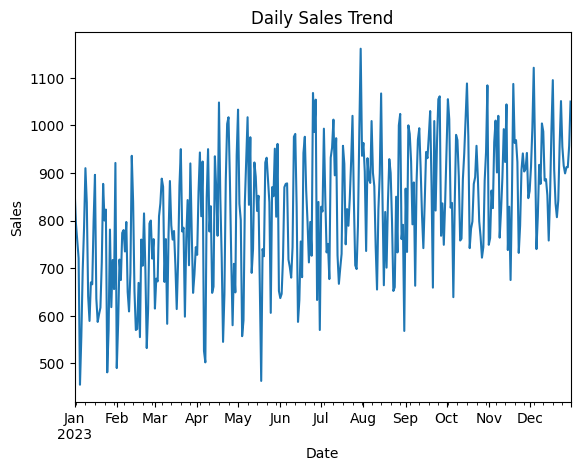

In [6]:
daily_sales = df.groupby('date')['sales'].sum()

plt.figure()
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

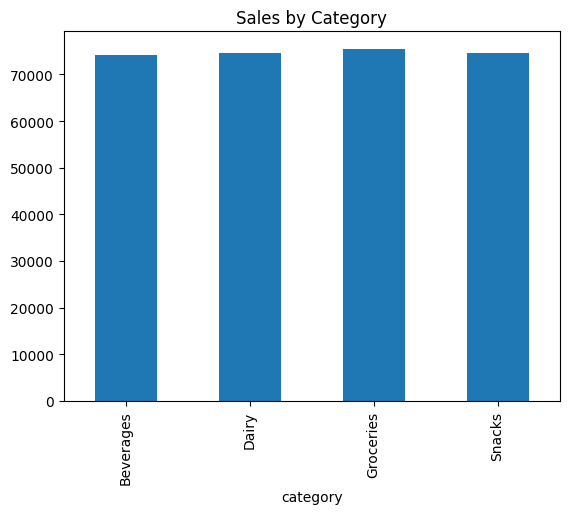

In [7]:
category_sales = df.groupby('category')['sales'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

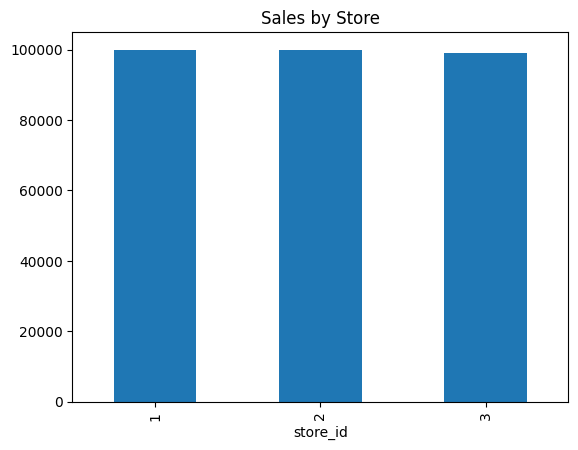

In [8]:
store_sales = df.groupby('store_id')['sales'].sum()

plt.figure()
store_sales.plot(kind='bar')
plt.title("Sales by Store")
plt.show()

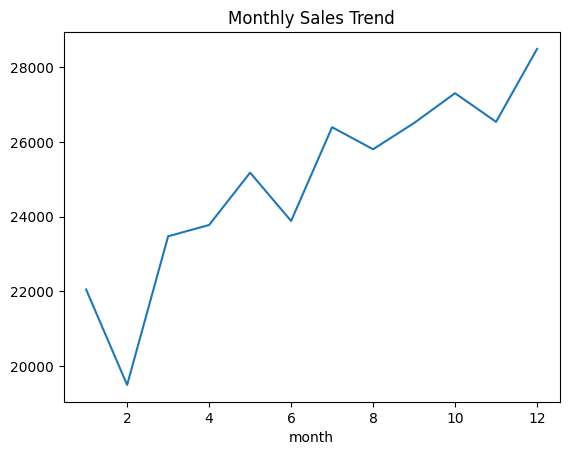

In [10]:
df['month'] = df['date'].dt.month

monthly_sales = df.groupby('month')['sales'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()